# Notebook 2: SRKW call sequence analysis

# Imports

In [4]:
import os
import glob
import warnings

import joblib
import librosa
import librosa.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")


# Load saved pipeline from Notebook 1

In [5]:
scaler = joblib.load("scaler.pkl")
pca = joblib.load("pca_2d.pkl")
kmeans = joblib.load("kmeans.pkl")

n_features_expected = int(scaler.n_features_in_)
print(f"Scaler expects {n_features_expected} input features.")

print(f"PCA components retained: {pca.n_components_}")
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"PCA cumulative variance explained: {float(np.sum(pca.explained_variance_ratio_)):.3f}")

print(f"K-Means n_clusters: {kmeans.n_clusters}")
print(f"K-Means cluster center matrix shape: {kmeans.cluster_centers_.shape}")


Scaler expects 83 input features.
PCA components retained: 2
PCA explained variance ratio: [0.3430475  0.15673146]
PCA cumulative variance explained: 0.500
K-Means n_clusters: 40
K-Means cluster center matrix shape: (40, 83)


# Feature extraction function

In [6]:
TARGET_SR = 22050

def load_clip(filepath, target_sr=TARGET_SR):
    y, sr = librosa.load(filepath, sr=target_sr)
    return y, target_sr

def extract_features(y, sr):
    features = {}
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        features[f"mfcc_{i+1}_mean"] = np.mean(mfccs[i])
        features[f"mfcc_{i+1}_std"]  = np.std(mfccs[i])
    delta_mfccs = librosa.feature.delta(mfccs)
    for i in range(13):
        features[f"delta_mfcc_{i+1}_mean"] = np.mean(delta_mfccs[i])
        features[f"delta_mfcc_{i+1}_std"]  = np.std(delta_mfccs[i])
    cent = librosa.feature.spectral_centroid(y=y, sr=sr)
    features["spectral_centroid_mean"] = np.mean(cent)
    features["spectral_centroid_std"]  = np.std(cent)
    bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features["spectral_bandwidth_mean"] = np.mean(bw)
    features["spectral_bandwidth_std"]  = np.std(bw)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features["spectral_rolloff_mean"] = np.mean(rolloff)
    features["spectral_rolloff_std"]  = np.std(rolloff)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    for i in range(contrast.shape[0]):
        features[f"spectral_contrast_{i+1}_mean"] = np.mean(contrast[i])
    flatness = librosa.feature.spectral_flatness(y=y)
    features["spectral_flatness_mean"] = np.mean(flatness)
    features["spectral_flatness_std"]  = np.std(flatness)
    zcr = librosa.feature.zero_crossing_rate(y)
    features["zcr_mean"] = np.mean(zcr)
    features["zcr_std"]  = np.std(zcr)
    rms = librosa.feature.rms(y=y)
    features["rms_mean"] = np.mean(rms)
    features["rms_std"]  = np.std(rms)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    for i in range(12):
        features[f"chroma_{i+1}_mean"] = np.mean(chroma[i])
    return features

# Sanity check: produce 3 seconds of random noise, extract features,
# verify count == 80 and (if available) names align with what the scaler saw.
_test_y = np.random.randn(TARGET_SR * 3).astype(np.float32)
_test_feats = extract_features(_test_y, TARGET_SR)
_test_names = list(_test_feats.keys())
n_features_expected = int(scaler.n_features_in_)
print(f"Scaler expects {n_features_expected} input features.")

print(f"Extracted {len(_test_names)} features from sanity-check noise clip.")
assert len(_test_names) == n_features_expected, f"Expected {n_features_expected} features, got {len(_test_names)}"

# Some sklearn versions store feature_names_in_; if so, compare.
expected_names = getattr(scaler, "feature_names_in_", None)
if expected_names is not None:
    expected_names = list(expected_names)
    if expected_names == _test_names:
        print("Feature names and order MATCH the scaler from Notebook 1.")
    else:
        print("Feature names/order MISMATCH with scaler. Detailed report:")
        only_extracted = [n for n in _test_names if n not in expected_names]
        only_expected  = [n for n in expected_names if n not in _test_names]
        print(f"  Extracted but not expected: {only_extracted}")
        print(f"  Expected but not extracted: {only_expected}")
        # show ordering differences
        for i, (a, b) in enumerate(zip(_test_names, expected_names)):
            if a != b:
                print(f"  Order diff at index {i}: extracted='{a}' vs expected='{b}'")
                break
else:
    print("Scaler has no stored feature_names_in_ (older sklearn). "
          "Order alignment relies on extract_features matching Notebook 1 exactly.")


Scaler expects 83 input features.
Extracted 83 features from sanity-check noise clip.
Scaler has no stored feature_names_in_ (older sklearn). Order alignment relies on extract_features matching Notebook 1 exactly.


# Load and explore Pod.Cast data

Found at `/Volumes/Preston's 256gb/Datasets/orcasound_data`.

In [7]:
# UPDATE THIS PATH if the dataset lives elsewhere on disk.
PODCAST_DIR = "/Volumes/Preston's 256gb/Datasets/orcasound_data"

print(f"Searching under: {PODCAST_DIR}")
print(f"Path exists: {os.path.exists(PODCAST_DIR)}")

tsv_files = sorted(glob.glob(os.path.join(PODCAST_DIR, "**", "*.tsv"), recursive=True))
wav_files = sorted(glob.glob(os.path.join(PODCAST_DIR, "**", "*.wav"), recursive=True))

print(f"\nFound {len(tsv_files)} TSV files and {len(wav_files)} WAV files.")

def _show(paths, label, n=20):
    print(f"\n{label} (showing up to {n}):")
    for p in paths[:n]:
        print(f"  {p}")
    if len(paths) > n:
        print(f"  ... and {len(paths) - n} more")

_show(tsv_files, "TSV files")
_show(wav_files, "WAV files")

if tsv_files:
    first_tsv = tsv_files[0]
    print(f"\nFirst TSV: {first_tsv}")
    df_first = pd.read_csv(first_tsv, sep="\t")
    print(f"Columns: {list(df_first.columns)}")
    print("First 10 rows:")
    print(df_first.head(10))

    wav_col_candidates = [c for c in df_first.columns if "wav" in c.lower() or "file" in c.lower()]
    if wav_col_candidates:
        wcol = wav_col_candidates[0]
        print(f"\nUnique values in '{wcol}':")
        print(df_first[wcol].unique())
    else:
        print("\nNo obvious wav_filename column found in first TSV.")
else:
    print("No TSV files found — update PODCAST_DIR.")


Searching under: /Volumes/Preston's 256gb/Datasets/orcasound_data
Path exists: True

Found 2 TSV files and 2975 WAV files.

TSV files (showing up to 20):
  /Volumes/Preston's 256gb/Datasets/orcasound_data/TestDataLatest_PodCastAllRounds_123/test.tsv
  /Volumes/Preston's 256gb/Datasets/orcasound_data/TrainDataLatest_PodCastAllRounds_123567910/annotations.tsv

WAV files (showing up to 20):
  /Volumes/Preston's 256gb/Datasets/orcasound_data/TestDataLatest_PodCastAllRounds_123/wav/OS_7_05_2019_08_24_00_.wav
  /Volumes/Preston's 256gb/Datasets/orcasound_data/TestDataLatest_PodCastAllRounds_123/wav/OS_9_27_2017_08_14_00__0001.wav
  /Volumes/Preston's 256gb/Datasets/orcasound_data/TestDataLatest_PodCastAllRounds_123/wav/OS_9_27_2017_08_19_00__0002.wav
  /Volumes/Preston's 256gb/Datasets/orcasound_data/TestDataLatest_PodCastAllRounds_123/wav/OS_9_27_2017_08_25_00__0003.wav
  /Volumes/Preston's 256gb/Datasets/orcasound_data/TestDataLatest_PodCastAllRounds_123/wav/OS_9_27_2017_08_25_00__0004.wav

# Parse all annotations

Dropped 715 rows with missing start_time_s or non-positive duration.

MIN_ANNOTATIONS_PER_WAV=2: dropped 2109 WAV file(s) with too few annotations; removed 2109 / 5650 annotation rows (37.3%).

Total annotations (after per-WAV annotation-count filter): 3541
Unique sessions:    283

Calls per session:
session_id
OS_7_05_2019_08_24_00_                   523
60026                                    264
64031                                    178
1562337136_0005                           38
64030                                     35
                                        ... 
67025000b                                  2
OS_9_27_2017_10_07_00__0001                2
1562340736_0001                            2
780210003                                  2
rpi-port-townsend_2020_09_29_19_17_00      2
Length: 283, dtype: int64


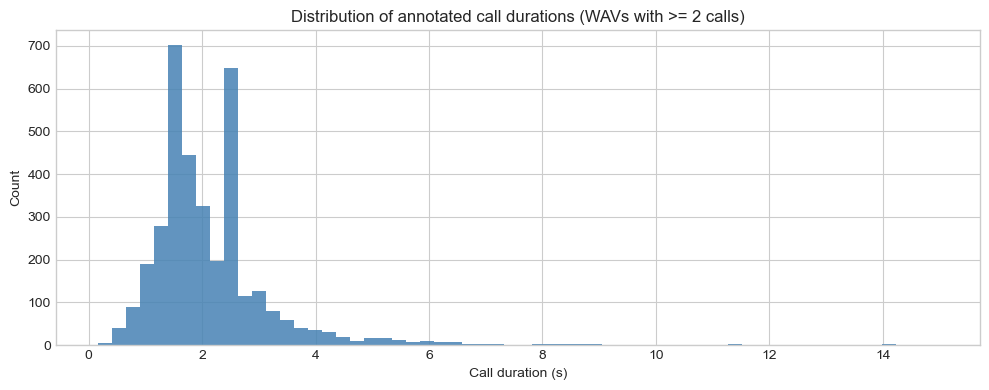

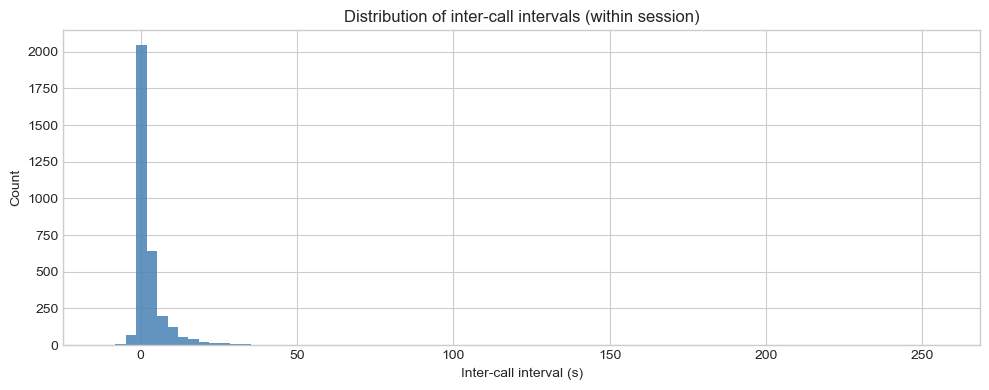

In [8]:
def _normalize_columns(df):
    rename = {}
    for col in df.columns:
        lc = col.lower()
        if "wav" in lc and ("file" in lc or "name" in lc):
            rename[col] = "wav_filename"
        elif "start" in lc and "time" in lc:
            rename[col] = "start_time_s"
        elif "begin" in lc and "time" in lc:
            rename[col] = "start_time_s"
        elif lc in ("start", "start_s"):
            rename[col] = "start_time_s"
        elif "duration" in lc:
            rename[col] = "duration_s"
        elif "end" in lc and "time" in lc:
            rename[col] = "end_time_s"
    return df.rename(columns=rename)

frames = []
for tsv in tsv_files:
    try:
        df = pd.read_csv(tsv, sep="\t")
    except Exception as e:
        print(f"Could not read {tsv}: {e}")
        continue
    df = _normalize_columns(df)

    if "wav_filename" not in df.columns:
        print(f"Skipping {tsv}: no wav_filename column after normalization.")
        continue

    if "start_time_s" not in df.columns:
        print(f"Skipping {tsv}: no start_time_s column after normalization.")
        continue

    if "duration_s" not in df.columns:
        if "end_time_s" in df.columns:
            df["duration_s"] = df["end_time_s"] - df["start_time_s"]
        else:
            print(f"Skipping {tsv}: no duration_s or end_time_s column.")
            continue

    df["source_tsv"] = tsv
    frames.append(df[["wav_filename", "start_time_s", "duration_s", "source_tsv"]])

if not frames:
    raise RuntimeError("No usable annotations found across TSV files.")

annot = pd.concat(frames, ignore_index=True)
annot["start_time_s"] = pd.to_numeric(annot["start_time_s"], errors="coerce")
annot["duration_s"]   = pd.to_numeric(annot["duration_s"],   errors="coerce")

before = len(annot)
annot = annot.dropna(subset=["start_time_s", "wav_filename"])
annot = annot[annot["duration_s"] > 0]
after = len(annot)
print(f"Dropped {before - after} rows with missing start_time_s or non-positive duration.")

annot["end_time_s"] = annot["start_time_s"] + annot["duration_s"]
annot["session_id"] = annot["wav_filename"].astype(str).apply(
    lambda x: os.path.splitext(os.path.basename(x))[0]
)
annot = annot.sort_values(["session_id", "start_time_s"]).reset_index(drop=True)

# Drop entire WAV files with fewer than two annotated calls (no within-file transitions).
MIN_ANNOTATIONS_PER_WAV = 2
_annot_per_wav = annot.groupby("wav_filename", sort=False).size()
_wavs_before = int(_annot_per_wav.shape[0])
_rows_before = len(annot)
_keep_wavs = _annot_per_wav[_annot_per_wav >= MIN_ANNOTATIONS_PER_WAV].index
_dropped_wavs = _wavs_before - int(len(_keep_wavs))
annot = annot[annot["wav_filename"].isin(_keep_wavs)].copy().reset_index(drop=True)
annot["end_time_s"] = annot["start_time_s"] + annot["duration_s"]
_rows_after = len(annot)
_rows_dropped = _rows_before - _rows_after
print(
    f"\nMIN_ANNOTATIONS_PER_WAV={MIN_ANNOTATIONS_PER_WAV}: dropped {_dropped_wavs} WAV file(s) "
    f"with too few annotations; removed {_rows_dropped} / {_rows_before} annotation rows "
    f"({_rows_dropped / max(_rows_before, 1):.1%})."
)

print(f"\nTotal annotations (after per-WAV annotation-count filter): {len(annot)}")
print(f"Unique sessions:    {annot['session_id'].nunique()}")
print("\nCalls per session:")
print(annot.groupby("session_id").size().sort_values(ascending=False))

# Histogram of call durations
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(annot["duration_s"], bins=60, color="steelblue", alpha=0.85)
ax.set_xlabel("Call duration (s)")
ax.set_ylabel("Count")
ax.set_title("Distribution of annotated call durations (WAVs with >= 2 calls)")
plt.tight_layout()
plt.show()

# Histogram of inter-call intervals within each session
ici = []
for sid, grp in annot.groupby("session_id"):
    g = grp.sort_values("start_time_s")
    gaps = g["start_time_s"].values[1:] - g["end_time_s"].values[:-1]
    ici.extend(gaps.tolist())
ici = np.array(ici, dtype=float)

fig, ax = plt.subplots(figsize=(10, 4))
if len(ici) > 0:
    ax.hist(ici, bins=80, color="steelblue", alpha=0.85)
    ax.set_xlabel("Inter-call interval (s)")
    ax.set_ylabel("Count")
    ax.set_title("Distribution of inter-call intervals (within session)")
else:
    ax.text(0.5, 0.5, "No inter-call intervals (sessions had <=1 call).",
            ha="center", va="center", transform=ax.transAxes)
plt.tight_layout()
plt.show()


# Verify WAV file access

In [9]:
# Index every WAV under PODCAST_DIR by its basename for quick lookup.
wav_index = {}
for p in wav_files:
    wav_index.setdefault(os.path.basename(p), p)

wav_path_map = {}
missing = []
for ref in annot["wav_filename"].unique():
    base = os.path.basename(str(ref))
    direct = os.path.join(PODCAST_DIR, str(ref))
    if os.path.exists(direct):
        wav_path_map[ref] = direct
    elif base in wav_index:
        wav_path_map[ref] = wav_index[base]
    else:
        missing.append(ref)

print(f"WAVs referenced by annotations: {annot['wav_filename'].nunique()}")
print(f"WAVs found on disk:             {len(wav_path_map)}")
print(f"WAVs missing:                   {len(missing)}")

if missing:
    print("\nMissing WAVs and number of annotations referencing them:")
    miss_counts = annot[annot["wav_filename"].isin(missing)]["wav_filename"].value_counts()
    for name, count in miss_counts.items():
        print(f"  {name}: {count} annotations")

summary_rows = []
for ref, full in wav_path_map.items():
    try:
        _ = librosa.load(full, sr=TARGET_SR, duration=0.1)
        dur = librosa.get_duration(path=full)
        ok = True
    except Exception as e:
        dur = float("nan")
        ok = False
        print(f"Could not read {full}: {e}")
    n_annot = int((annot["wav_filename"] == ref).sum())
    summary_rows.append({
        "wav_filename": ref,
        "exists": ok,
        "file_duration_s": dur,
        "number_of_annotations": n_annot,
    })

wav_summary = pd.DataFrame(summary_rows).sort_values("number_of_annotations", ascending=False)
print("\nWAV summary:")
print(wav_summary.to_string(index=False))


WAVs referenced by annotations: 283
WAVs found on disk:             283
WAVs missing:                   0

WAV summary:
                                   wav_filename  exists  file_duration_s  number_of_annotations
                     OS_7_05_2019_08_24_00_.wav    True      1800.160000                    523
                                      60026.wav    True      1740.000000                    264
                                      64031.wav    True       783.738300                    178
                            1562337136_0005.wav    True        61.250000                     38
                                      64030.wav    True       484.244650                     35
                                      60012.wav    True       356.700200                     33
                OS_9_27_2017_09_02_00__0002.wav    True        61.250000                     30
                OS_9_27_2017_09_02_00__0001.wav    True        61.250000                     26
                

# Slice calls and extract features

In [10]:
results = []
skipped = []

annot = annot.sort_values(["session_id", "start_time_s"]).reset_index(drop=True)
annot["call_index"] = annot.groupby("session_id").cumcount()
total = len(annot)

for i, row in enumerate(annot.itertuples(index=False), start=1):
    ref = row.wav_filename
    full = wav_path_map.get(ref)
    if full is None:
        skipped.append((ref, row.start_time_s, "wav_not_found"))
    else:
        try:
            y, sr = librosa.load(full, sr=TARGET_SR,
                                 offset=float(row.start_time_s),
                                 duration=float(row.duration_s))
            if y.size < 512:
                raise ValueError(f"segment too short for STFT ({y.size} samples)")
            feats = extract_features(y, sr)
            feat_names = list(feats.keys())
            feat_vec = np.array([feats[n] for n in feat_names], dtype=float).reshape(1, -1)
            scaled = scaler.transform(feat_vec)
            pcs = pca.transform(scaled)
            rec = {
                "session_id":   row.session_id,
                "wav_filename": ref,
                "start_time_s": float(row.start_time_s),
                "end_time_s":   float(row.end_time_s),
                "duration_s":   float(row.duration_s),
                "call_index":   int(row.call_index),
                "pca_0":        float(pcs[0, 0]),
                "pca_1":        float(pcs[0, 1]) if pcs.shape[1] > 1 else float("nan"),
            }
            for n, v in feats.items():
                rec[n] = float(v)
            results.append(rec)
        except Exception as e:
            skipped.append((ref, float(row.start_time_s), str(e)))

    if i % 50 == 0 or i == total:
        print(f"Processed {i}/{total} calls ({len(skipped)} skipped)")

calls_df = pd.DataFrame(results)
print(f"\nSuccessfully processed: {len(calls_df)}")
print(f"Skipped:                {len(skipped)}")
if total > 0:
    print(f"Skip rate:              {len(skipped) / total:.1%}")

print(f"\nDataFrame shape: {calls_df.shape}")
print("First 5 rows:")
print(calls_df.head())


Processed 50/3541 calls (0 skipped)
Processed 100/3541 calls (0 skipped)
Processed 150/3541 calls (0 skipped)
Processed 200/3541 calls (0 skipped)
Processed 250/3541 calls (0 skipped)
Processed 300/3541 calls (0 skipped)
Processed 350/3541 calls (0 skipped)
Processed 400/3541 calls (0 skipped)
Processed 450/3541 calls (0 skipped)
Processed 500/3541 calls (0 skipped)
Processed 550/3541 calls (0 skipped)
Processed 600/3541 calls (0 skipped)
Processed 650/3541 calls (0 skipped)
Processed 700/3541 calls (0 skipped)
Processed 750/3541 calls (0 skipped)
Processed 800/3541 calls (0 skipped)
Processed 850/3541 calls (1 skipped)
Processed 900/3541 calls (1 skipped)
Processed 950/3541 calls (1 skipped)
Processed 1000/3541 calls (1 skipped)
Processed 1050/3541 calls (1 skipped)
Processed 1100/3541 calls (1 skipped)
Processed 1150/3541 calls (1 skipped)
Processed 1200/3541 calls (1 skipped)
Processed 1250/3541 calls (1 skipped)
Processed 1300/3541 calls (1 skipped)
Processed 1350/3541 calls (1 ski

# Apply K-Means labels from Notebook 1

Cluster distribution:
kmeans_label
0       37
1        4
3        1
6        8
7       50
11     386
14       4
16      77
17       9
18       1
19       1
20      28
23     162
24     150
26     134
27    1174
28       2
30       3
32    1053
33      27
34     118
36      40
37      15
38      14
39      41
Name: count, dtype: int64


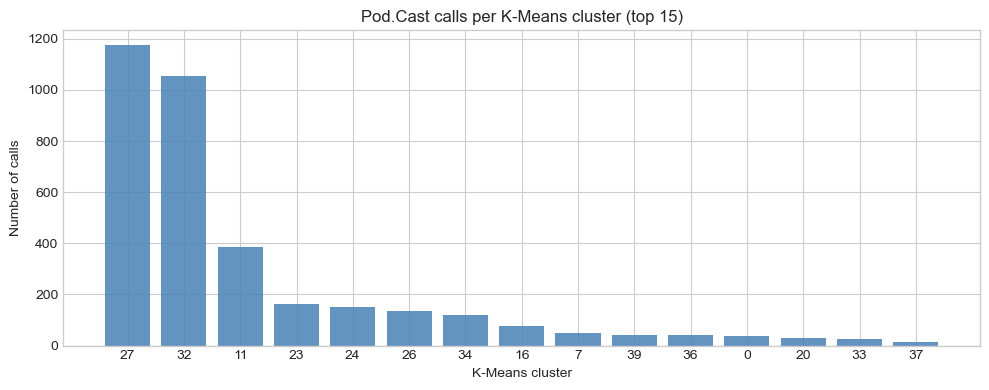

In [11]:
feature_cols = (
    list(getattr(scaler, "feature_names_in_", []))
    or [c for c in calls_df.columns
        if c not in {"session_id", "wav_filename", "start_time_s",
                     "end_time_s", "duration_s", "call_index", "pca_0", "pca_1"}]
)

X80 = calls_df[feature_cols].to_numpy(dtype=float)
X80_scaled = scaler.transform(X80)

calls_df["kmeans_label"] = kmeans.predict(X80_scaled)

cluster_counts = calls_df["kmeans_label"].value_counts().sort_index()
print("Cluster distribution:")
print(cluster_counts)

top = cluster_counts.sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top.index.astype(str), top.values, color="steelblue", alpha=0.85)
ax.set_xlabel("K-Means cluster")
ax.set_ylabel("Number of calls")
ax.set_title("Pod.Cast calls per K-Means cluster (top 15)")
plt.tight_layout()
plt.show()


# Save processed data

In [12]:
pkl_path = "podcast_calls_processed.pkl"
csv_path = "podcast_calls_processed.csv"

joblib.dump(calls_df, pkl_path)
calls_df.to_csv(csv_path, index=False)

pkl_size = os.path.getsize(pkl_path) / 1e6
csv_size = os.path.getsize(csv_path) / 1e6
print(f"Saved {pkl_path} ({pkl_size:.2f} MB)")
print(f"Saved {csv_path} ({csv_size:.2f} MB)")


Saved podcast_calls_processed.pkl (2.64 MB)
Saved podcast_calls_processed.csv (6.10 MB)


# K-Means transition analysis


In [13]:
MIN_CALLS_PER_SESSION = 2
session_sizes = calls_df.groupby("session_id").size()
valid_sessions = session_sizes[session_sizes >= MIN_CALLS_PER_SESSION].index
df_filt = calls_df[calls_df["session_id"].isin(valid_sessions)].copy()
df_filt = df_filt.sort_values(["session_id", "start_time_s"]).reset_index(drop=True)

n_dropped = int(session_sizes.shape[0] - len(valid_sessions))
print(f"Sessions with >= {MIN_CALLS_PER_SESSION} calls: {len(valid_sessions)}  (dropped {n_dropped})")
print(f"Calls in filtered data: {len(df_filt)}")

labels_sorted = sorted(df_filt["kmeans_label"].unique())
n_labels = len(labels_sorted)
label_to_idx = {lab: i for i, lab in enumerate(labels_sorted)}

count_mat = np.zeros((n_labels, n_labels), dtype=int)
for sid, grp in df_filt.groupby("session_id"):
    seq = grp.sort_values("start_time_s")["kmeans_label"].values
    for a, b in zip(seq[:-1], seq[1:]):
        count_mat[label_to_idx[a], label_to_idx[b]] += 1

total_transitions = int(count_mat.sum())
print(f"Total within-session transitions counted: {total_transitions}")

label_strs = [str(l) for l in labels_sorted]
trans_counts = pd.DataFrame(count_mat, index=label_strs, columns=label_strs)

row_sums = count_mat.sum(axis=1, keepdims=True).astype(float)
row_sums[row_sums == 0] = 1.0
prob_mat = count_mat / row_sums
trans_probs = pd.DataFrame(prob_mat, index=label_strs, columns=label_strs)
print(f"Probability matrix shape: {trans_probs.shape}")


Sessions with >= 2 calls: 283  (dropped 0)
Calls in filtered data: 3539
Total within-session transitions counted: 3256
Probability matrix shape: (25, 25)


# K-Means transition heatmap


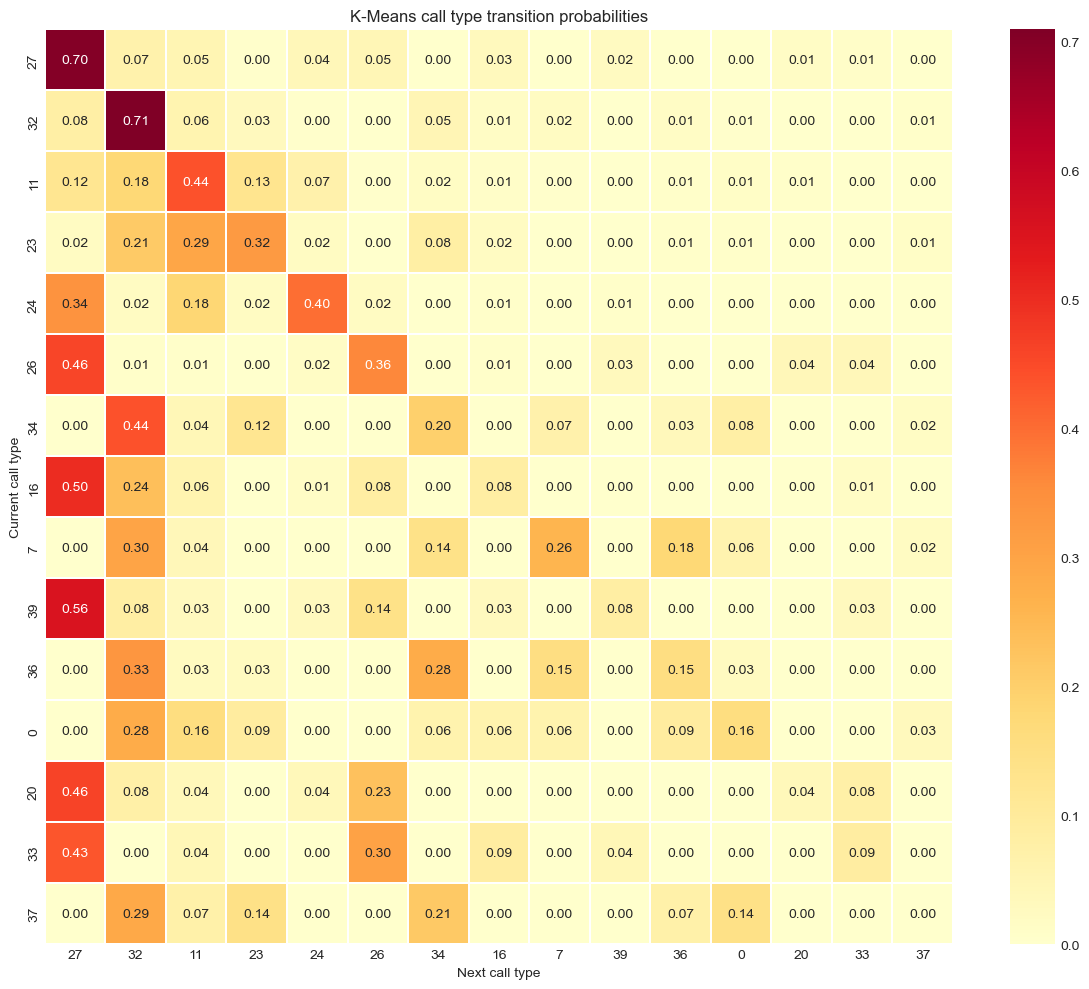


Top 10 strongest transitions (excluding self-loops):
  Type 3 -> Type 24: P = 1.00
  Type 18 -> Type 32: P = 1.00
  Type 19 -> Type 27: P = 1.00
  Type 38 -> Type 32: P = 0.77
  Type 1 -> Type 39: P = 0.67
  Type 30 -> Type 26: P = 0.67
  Type 6 -> Type 27: P = 0.57
  Type 17 -> Type 27: P = 0.56
  Type 39 -> Type 27: P = 0.56
  Type 16 -> Type 27: P = 0.50

Top 5 self-loop probabilities:
  Type 32 -> Type 32: P = 0.71
  Type 27 -> Type 27: P = 0.70
  Type 11 -> Type 11: P = 0.44
  Type 24 -> Type 24: P = 0.40
  Type 26 -> Type 26: P = 0.36


In [14]:
plot_probs = trans_probs.copy()
plot_labels = label_strs

if len(label_strs) > 15:
    top_labels = (
        df_filt["kmeans_label"]
        .value_counts()
        .head(15)
        .index
        .astype(str)
        .tolist()
    )
    plot_probs = trans_probs.loc[top_labels, top_labels]
    plot_labels = top_labels

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    plot_probs.astype(float),
    annot=True, fmt=".2f", cmap="YlOrRd",
    xticklabels=plot_labels, yticklabels=plot_labels,
    linewidths=0.3, ax=ax,
)
ax.set_xlabel("Next call type")
ax.set_ylabel("Current call type")
ax.set_title("K-Means call type transition probabilities")
plt.tight_layout()
plt.show()

print("\nTop 10 strongest transitions (excluding self-loops):")
_rows = []
for i, ri in enumerate(labels_sorted):
    for j, rj in enumerate(labels_sorted):
        if i != j:
            _rows.append((str(ri), str(rj), prob_mat[i, j]))
_rows.sort(key=lambda x: x[2], reverse=True)
for src, dst, p in _rows[:10]:
    print(f"  Type {src} -> Type {dst}: P = {p:.2f}")

print("\nTop 5 self-loop probabilities:")
_self = [(str(labels_sorted[i]), prob_mat[i, i]) for i in range(n_labels)]
_self.sort(key=lambda x: x[1], reverse=True)
for lab, p in _self[:5]:
    print(f"  Type {lab} -> Type {lab}: P = {p:.2f}")


# Prepare sequences for HMM


In [15]:
pca_cols = ["pca_0", "pca_1"]
session_order = []
lengths_hmm = []
x_parts = []

for sid, grp in df_filt.groupby("session_id", sort=False):
    grp_sorted = grp.sort_values("start_time_s")
    x_parts.append(grp_sorted[pca_cols].to_numpy(dtype=float))
    lengths_hmm.append(len(grp_sorted))
    session_order.append(sid)

X_hmm = np.vstack(x_parts)
session_ids_ordered = session_order

assert X_hmm.shape[0] == sum(lengths_hmm), (
    f"Shape mismatch: X_hmm has {X_hmm.shape[0]} rows but sum(lengths)={sum(lengths_hmm)}"
)
print(f"X_hmm shape:        {X_hmm.shape}")
print(f"Number of sequences: {len(lengths_hmm)}")
print(f"Total calls:         {X_hmm.shape[0]}")
print(f"Sequence lengths — min: {min(lengths_hmm)}, max: {max(lengths_hmm)}, "
      f"mean: {np.mean(lengths_hmm):.1f}")


X_hmm shape:        (3539, 2)
Number of sequences: 283
Total calls:         3539
Sequence lengths — min: 2, max: 522, mean: 12.5


# HMM: sweep number of hidden states


In [16]:
from hmmlearn.hmm import GaussianHMM

def compute_hmm_bic(model, X, lengths):
    n_samples = X.shape[0]
    d = X.shape[1]
    k = model.n_components
    n_params = (k * k - k) + (k * d) + (k * d * (d + 1) // 2) + (k - 1)
    log_likelihood = model.score(X, lengths=lengths) * n_samples
    bic = -2 * log_likelihood + n_params * np.log(n_samples)
    return bic, log_likelihood

n_states_range = [3, 4, 5, 6, 7, 8, 10, 12, 15, 20, 25, 30]
bic_results = []

for n in n_states_range:
    try:
        hmm_model = GaussianHMM(
            n_components=n,
            covariance_type="full",
            n_iter=200,
            random_state=42,
        )
        hmm_model.fit(X_hmm, lengths=lengths_hmm)
        bic, ll = compute_hmm_bic(hmm_model, X_hmm, lengths_hmm)
        converged = hmm_model.monitor_.converged
        bic_results.append({
            "n_components": n,
            "bic": bic,
            "log_likelihood": ll,
            "converged": converged,
        })
        print(f"  n={n:2d} | BIC={bic:.1f} | LL={ll:.1f} | converged={converged}")
    except Exception as e:
        print(f"  n={n:2d} | FAILED: {e}")

bic_df = pd.DataFrame(bic_results)
print(f"\nCompleted {len(bic_df)} / {len(n_states_range)} fits.")


  n= 3 | BIC=162361308.8 | LL=-81180560.4 | converged=True
  n= 4 | BIC=143251690.4 | LL=-71625702.2 | converged=True
  n= 5 | BIC=143231901.0 | LL=-71615750.3 | converged=True
  n= 6 | BIC=143197888.7 | LL=-71598678.8 | converged=True
  n= 7 | BIC=135095908.5 | LL=-67547615.1 | converged=True
  n= 8 | BIC=131602876.9 | LL=-65801017.6 | converged=True
  n=10 | BIC=130716234.4 | LL=-65357508.4 | converged=True
  n=12 | BIC=130465035.2 | LL=-65231688.2 | converged=True
  n=15 | BIC=127512514.8 | LL=-63755035.7 | converged=True
  n=20 | BIC=127793943.4 | LL=-63894932.9 | converged=True
  n=25 | BIC=124127516.4 | LL=-62060698.0 | converged=True
  n=30 | BIC=124052664.6 | LL=-62022046.3 | converged=True

Completed 12 / 12 fits.


# HMM: BIC results


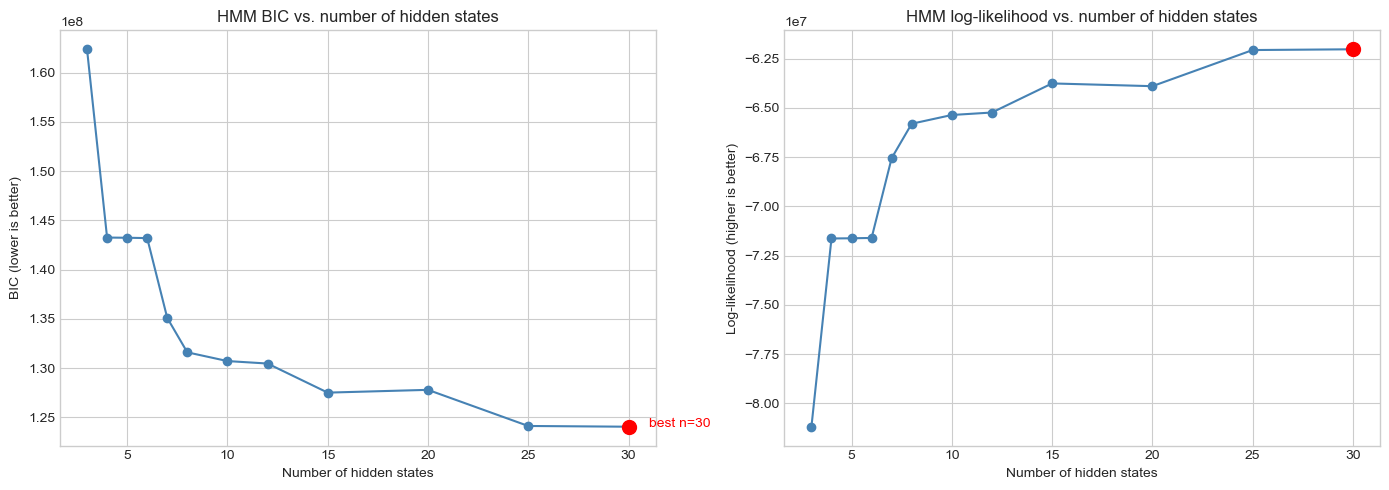

Optimal number of hidden states by BIC: 30
BIC at optimum: 124052664.6

All fits converged.


In [17]:
best_idx = int(bic_df["bic"].idxmin())
best_n = int(bic_df.loc[best_idx, "n_components"])
best_bic = float(bic_df.loc[best_idx, "bic"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(bic_df["n_components"], bic_df["bic"], "o-", color="steelblue")
ax1.plot(best_n, best_bic, "ro", markersize=10, zorder=5)
ax1.annotate(f"best n={best_n}", xy=(best_n, best_bic),
             xytext=(best_n + 1, best_bic), fontsize=10, color="red")
ax1.set_xlabel("Number of hidden states")
ax1.set_ylabel("BIC (lower is better)")
ax1.set_title("HMM BIC vs. number of hidden states")

best_ll_idx = int(bic_df["log_likelihood"].idxmax())
best_ll_n = int(bic_df.loc[best_ll_idx, "n_components"])
best_ll = float(bic_df.loc[best_ll_idx, "log_likelihood"])

ax2.plot(bic_df["n_components"], bic_df["log_likelihood"], "o-", color="steelblue")
ax2.plot(best_ll_n, best_ll, "ro", markersize=10, zorder=5)
ax2.set_xlabel("Number of hidden states")
ax2.set_ylabel("Log-likelihood (higher is better)")
ax2.set_title("HMM log-likelihood vs. number of hidden states")

plt.tight_layout()
plt.show()

print(f"Optimal number of hidden states by BIC: {best_n}")
print(f"BIC at optimum: {best_bic:.1f}")

not_converged = bic_df[~bic_df["converged"]]
if len(not_converged) > 0:
    print(f"\nFits that did NOT converge: n_components = {not_converged['n_components'].tolist()}")
else:
    print("\nAll fits converged.")


# Fit final HMM


In [18]:
final_hmm = GaussianHMM(
    n_components=best_n,
    covariance_type="full",
    n_iter=300,
    random_state=42,
)
final_hmm.fit(X_hmm, lengths=lengths_hmm)

print(f"Final HMM converged: {final_hmm.monitor_.converged}")
print(f"\nTransition matrix ({best_n} x {best_n}):")
with np.printoptions(precision=3, suppress=True, linewidth=120):
    print(final_hmm.transmat_)

print(f"\nState means (PCA coordinates):")
for s in range(best_n):
    m = final_hmm.means_[s]
    print(f"  State {s}: PC1={m[0]:.2f}, PC2={m[1]:.2f}")

states = final_hmm.predict(X_hmm, lengths=lengths_hmm)
df_filt = df_filt.copy()
df_filt["hmm_state"] = states

print(f"\nHMM state distribution:")
state_dist = df_filt["hmm_state"].value_counts().sort_index()
print(state_dist)

print(f"\nHMM state counts per session (first 20 sessions):")
ct = pd.crosstab(df_filt["session_id"], df_filt["hmm_state"])
print(ct.head(20))


Final HMM converged: True

Transition matrix (30 x 30):
[[0.    0.    0.    0.    0.    0.    0.    0.    0.325 0.    0.252 0.    0.    0.    0.    0.328 0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.095 0.   ]
 [0.    0.    0.    1.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.829 0.    0.    0.    0.03  0.    0.    0.    0.    0.023 0.    0.    0.    0.
  0.    0.    0.    0.117 0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.925 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.035 0.    0.    0.    0.
  0.    0.    0.    0.    0.04  0.    0.    0.    0.    0.    0.   ]
 [0.02  0.    0.    0.    0.    0.    0.015 0.    0.    0.    0.    0.965 0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.992 0.    0.    0.

# HMM transition matrix


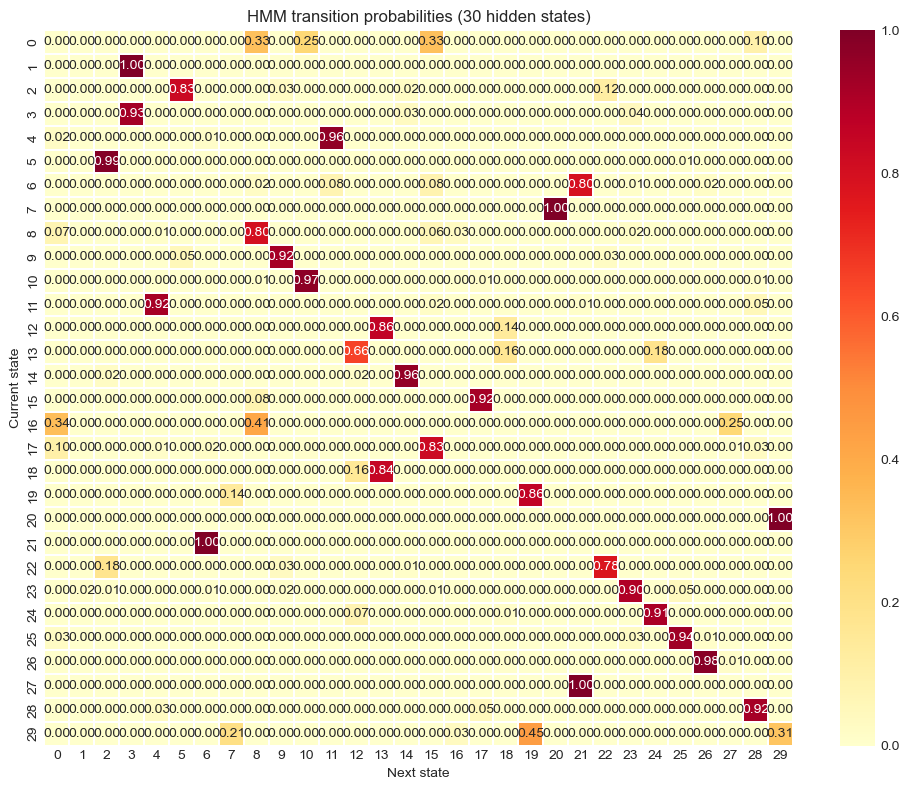


Top 10 strongest transitions (excluding self-loops):
  State 1 -> State 3: P = 1.00
  State 27 -> State 21: P = 1.00
  State 20 -> State 29: P = 1.00
  State 7 -> State 20: P = 1.00
  State 21 -> State 6: P = 1.00
  State 5 -> State 2: P = 0.99
  State 4 -> State 11: P = 0.96
  State 11 -> State 4: P = 0.92
  State 15 -> State 17: P = 0.92
  State 12 -> State 13: P = 0.86

Top 5 self-loop probabilities:
  State 26 -> State 26: P = 0.98
  State 10 -> State 10: P = 0.97
  State 14 -> State 14: P = 0.96
  State 25 -> State 25: P = 0.94
  State 3 -> State 3: P = 0.93

Highest self-loop: State 26 (P = 0.98) — most likely to repeat
Lowest self-loop:  State 16 (P = 0.00) — most likely to transition


In [19]:
hmm_trans = pd.DataFrame(
    final_hmm.transmat_,
    index=[str(i) for i in range(best_n)],
    columns=[str(i) for i in range(best_n)],
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    hmm_trans.astype(float),
    annot=True, fmt=".2f", cmap="YlOrRd",
    xticklabels=True, yticklabels=True,
    linewidths=0.3, ax=ax,
)
ax.set_xlabel("Next state")
ax.set_ylabel("Current state")
ax.set_title(f"HMM transition probabilities ({best_n} hidden states)")
plt.tight_layout()
plt.show()

tm = final_hmm.transmat_
print("\nTop 10 strongest transitions (excluding self-loops):")
_pairs = []
for i in range(best_n):
    for j in range(best_n):
        if i != j:
            _pairs.append((i, j, tm[i, j]))
_pairs.sort(key=lambda x: x[2], reverse=True)
for src, dst, p in _pairs[:10]:
    print(f"  State {src} -> State {dst}: P = {p:.2f}")

print("\nTop 5 self-loop probabilities:")
_self = [(i, tm[i, i]) for i in range(best_n)]
_self.sort(key=lambda x: x[1], reverse=True)
for s, p in _self[:5]:
    print(f"  State {s} -> State {s}: P = {p:.2f}")

highest_self = max(range(best_n), key=lambda i: tm[i, i])
lowest_self  = min(range(best_n), key=lambda i: tm[i, i])
print(f"\nHighest self-loop: State {highest_self} (P = {tm[highest_self, highest_self]:.2f}) — most likely to repeat")
print(f"Lowest self-loop:  State {lowest_self} (P = {tm[lowest_self, lowest_self]:.2f}) — most likely to transition")


# Save HMM results


In [20]:
joblib.dump(final_hmm, "hmm_model.pkl")
joblib.dump(df_filt, "podcast_calls_with_hmm.pkl")
hmm_trans.to_csv("hmm_transmat.csv")
trans_probs.to_csv("kmeans_transmat.csv")

for f in ["hmm_model.pkl", "podcast_calls_with_hmm.pkl", "hmm_transmat.csv", "kmeans_transmat.csv"]:
    sz = os.path.getsize(f) / 1e6
    print(f"Saved {f} ({sz:.2f} MB)")


Saved hmm_model.pkl (0.01 MB)
Saved podcast_calls_with_hmm.pkl (2.67 MB)
Saved hmm_transmat.csv (0.01 MB)
Saved kmeans_transmat.csv (0.01 MB)


# Compare K-Means vs HMM classifications


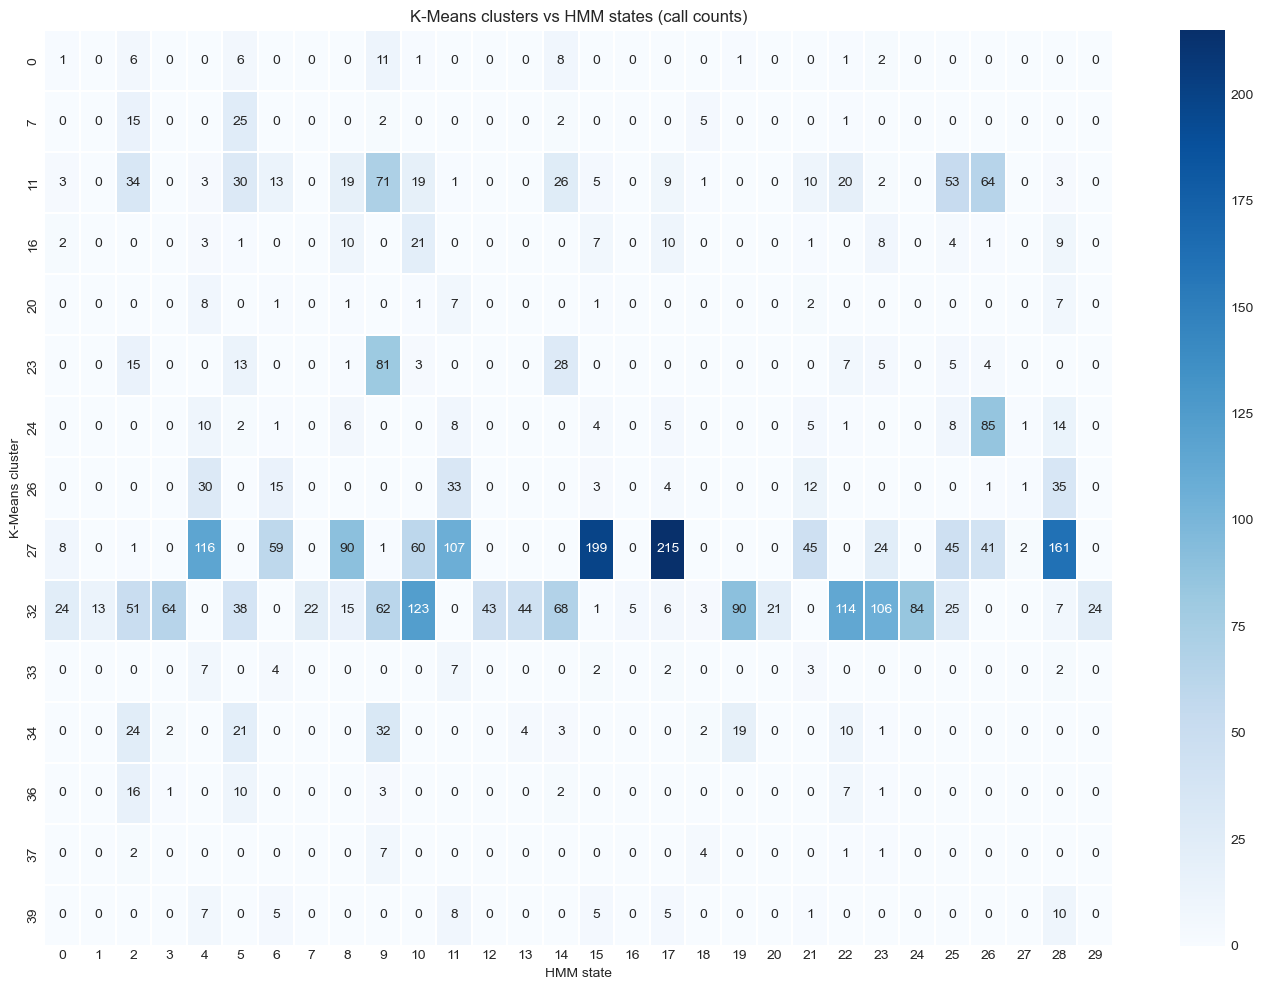


Top K-Means clusters per HMM state:
  HMM State 0: 63% from KM-32, 21% from KM-27
  HMM State 1: 100% from KM-32, 0% from KM-0
  HMM State 2: 31% from KM-32, 20% from KM-11
  HMM State 3: 96% from KM-32, 3% from KM-34
  HMM State 4: 62% from KM-27, 16% from KM-26
  HMM State 5: 26% from KM-32, 20% from KM-11
  HMM State 6: 60% from KM-27, 15% from KM-26
  HMM State 7: 100% from KM-32, 0% from KM-0
  HMM State 8: 63% from KM-27, 13% from KM-11
  HMM State 9: 30% from KM-23, 26% from KM-11
  HMM State 10: 54% from KM-32, 26% from KM-27
  HMM State 11: 61% from KM-27, 19% from KM-26
  HMM State 12: 100% from KM-32, 0% from KM-0
  HMM State 13: 90% from KM-32, 8% from KM-34
  HMM State 14: 45% from KM-32, 19% from KM-23
  HMM State 15: 86% from KM-27, 3% from KM-16
  HMM State 16: 100% from KM-32, 0% from KM-0
  HMM State 17: 83% from KM-27, 4% from KM-16
  HMM State 18: 31% from KM-7, 25% from KM-37
  HMM State 19: 82% from KM-32, 17% from KM-34
  HMM State 20: 100% from KM-32, 0% from K

In [21]:
from sklearn.metrics import normalized_mutual_info_score, silhouette_score

ct = pd.crosstab(df_filt["kmeans_label"], df_filt["hmm_state"])

plot_ct = ct
if ct.shape[0] > 15:
    top15 = df_filt["kmeans_label"].value_counts().head(15).index
    plot_ct = ct.loc[ct.index.isin(top15)]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(plot_ct, annot=True, fmt="d", cmap="Blues", ax=ax, linewidths=0.3)
ax.set_xlabel("HMM state")
ax.set_ylabel("K-Means cluster")
ax.set_title("K-Means clusters vs HMM states (call counts)")
plt.tight_layout()
plt.show()

print("\nTop K-Means clusters per HMM state:")
for state in sorted(ct.columns):
    col = ct[state].sort_values(ascending=False)
    total = col.sum()
    if total == 0:
        continue
    top2 = col.head(2)
    parts = [f"{v/total:.0%} from KM-{k}" for k, v in top2.items()]
    print(f"  HMM State {state}: {', '.join(parts)}")

nmi = normalized_mutual_info_score(df_filt["kmeans_label"], df_filt["hmm_state"])
print(f"\nNormalized Mutual Information: {nmi:.3f}")
print("  (0 = completely independent assignments, 1 = identical assignments)")


# PCA scatter: K-Means vs HMM coloring


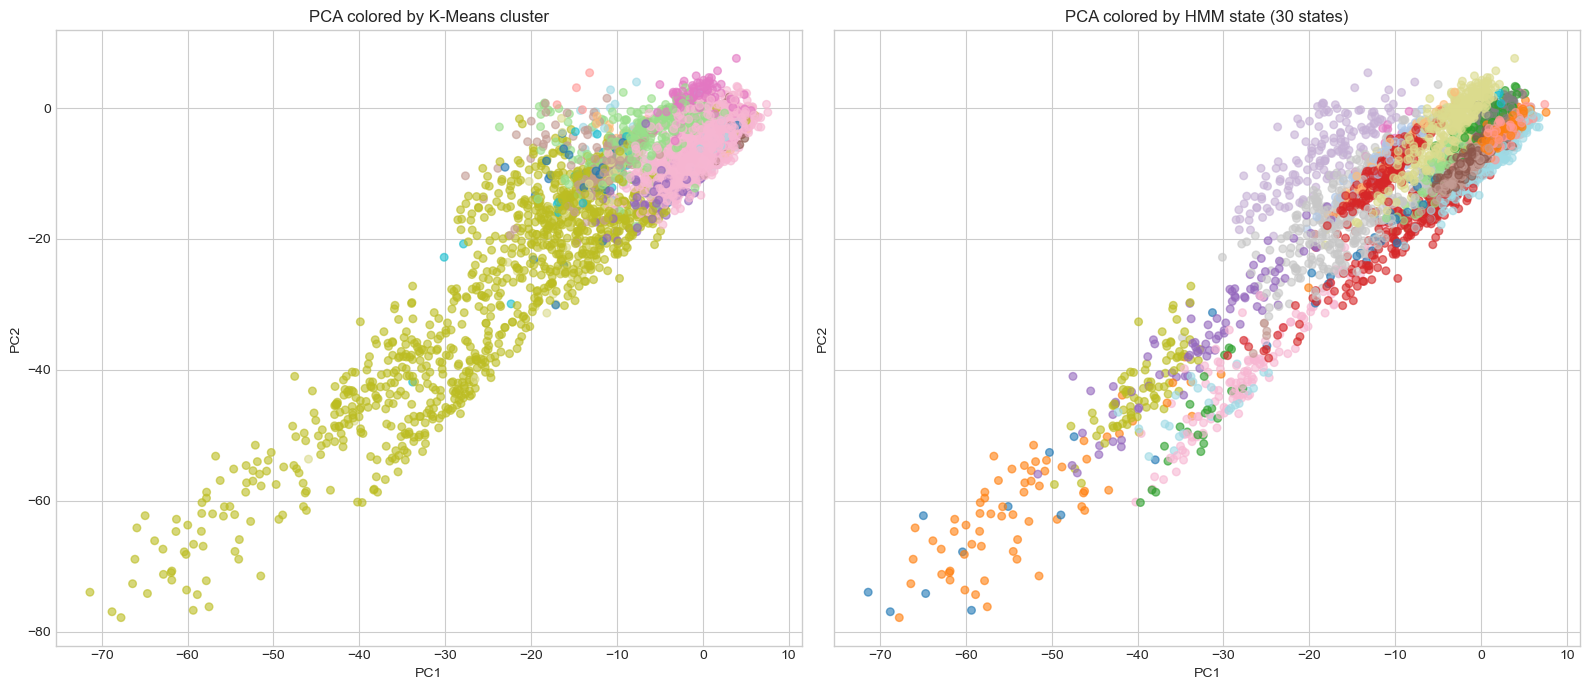

Silhouette score (K-Means labels on PCA): -0.329
Silhouette score (HMM states on PCA):     -0.142
HMM produces tighter clusters in PCA space.


In [22]:
pca_xy = df_filt[["pca_0", "pca_1"]].to_numpy(dtype=float)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

sc1 = ax1.scatter(df_filt["pca_0"], df_filt["pca_1"],
                   c=df_filt["kmeans_label"], cmap="tab20", alpha=0.6, s=30)
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_title("PCA colored by K-Means cluster")

sc2 = ax2.scatter(df_filt["pca_0"], df_filt["pca_1"],
                   c=df_filt["hmm_state"], cmap="tab20", alpha=0.6, s=30)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_title(f"PCA colored by HMM state ({best_n} states)")

plt.tight_layout()
plt.show()

sil_km = silhouette_score(pca_xy, df_filt["kmeans_label"])
sil_hmm = silhouette_score(pca_xy, df_filt["hmm_state"])
print(f"Silhouette score (K-Means labels on PCA): {sil_km:.3f}")
print(f"Silhouette score (HMM states on PCA):     {sil_hmm:.3f}")
if sil_hmm > sil_km:
    print("HMM produces tighter clusters in PCA space.")
elif sil_km > sil_hmm:
    print("K-Means produces tighter clusters in PCA space.")
else:
    print("Both produce equally tight clusters in PCA space.")


# Disagreement analysis


Total calls:     3539
Agree:           2152
Disagree:        1387
Agreement rate:  60.8%


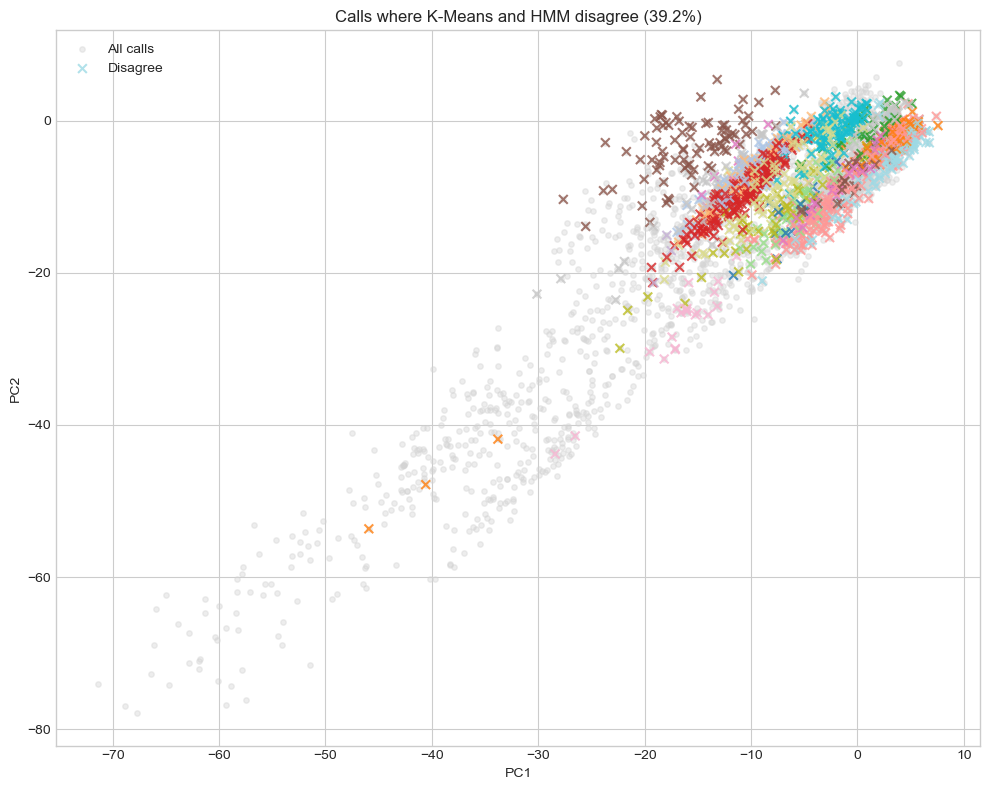

Disagreements indicate calls where sequential context changed the classification.


In [23]:
hmm_to_km = (
    df_filt.groupby("hmm_state")["kmeans_label"]
    .agg(lambda x: x.value_counts().idxmax())
    .to_dict()
)
df_filt["mapped_km"] = df_filt["hmm_state"].map(hmm_to_km)
df_filt["agree"] = df_filt["kmeans_label"] == df_filt["mapped_km"]

n_total = len(df_filt)
n_agree = int(df_filt["agree"].sum())
n_disagree = n_total - n_agree
disagree_pct = 100.0 * n_disagree / max(n_total, 1)

print(f"Total calls:     {n_total}")
print(f"Agree:           {n_agree}")
print(f"Disagree:        {n_disagree}")
print(f"Agreement rate:  {100 - disagree_pct:.1f}%")

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(df_filt["pca_0"], df_filt["pca_1"],
           c="lightgray", s=15, alpha=0.4, label="All calls")
dis = df_filt[~df_filt["agree"]]
ax.scatter(dis["pca_0"], dis["pca_1"],
           c=dis["hmm_state"], cmap="tab20", marker="x", s=40, alpha=0.8,
           label="Disagree")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Calls where K-Means and HMM disagree ({disagree_pct:.1f}%)")
ax.legend()
plt.tight_layout()
plt.show()

print("Disagreements indicate calls where sequential context changed the classification.")


# Build directed network helper functions


In [24]:
import networkx as nx
import plotly.graph_objects as go

def build_network_figure(transmat, labels, df, label_col, title, count_matrix=None):
    n = len(labels)
    lab_str = [str(l) for l in labels]

    G = nx.DiGraph()
    for l in lab_str:
        G.add_node(l)
    for i in range(n):
        for j in range(n):
            p = float(transmat[i, j])
            if p > 0:
                G.add_edge(lab_str[i], lab_str[j], weight=p)

    pos = nx.spring_layout(G, k=2, seed=42, iterations=50)

    freq = {}
    mean_pc1 = {}
    mean_pc2 = {}
    for l, ls in zip(labels, lab_str):
        sub = df[df[label_col] == l]
        freq[ls] = len(sub)
        mean_pc1[ls] = float(sub["pca_0"].mean()) if len(sub) else 0.0
        mean_pc2[ls] = float(sub["pca_1"].mean()) if len(sub) else 0.0

    fig = go.Figure()

    # Edges (non-self)
    for i in range(n):
        for j in range(n):
            p = float(transmat[i, j])
            if p <= 0 or i == j:
                continue
            src, tgt = lab_str[i], lab_str[j]
            x0, y0 = pos[src]
            x1, y1 = pos[tgt]
            width = max(p * 6, 0.5)
            opacity = min(0.9, max(0.15, p))
            cnt = int(count_matrix[i, j]) if count_matrix is not None else int(round(p * freq[src]))
            fig.add_trace(go.Scatter(
                x=[x0, x1, None], y=[y0, y1, None],
                mode="lines",
                line=dict(width=width, color=f"rgba(255,255,255,{opacity})"),
                hoverinfo="text",
                text=f"{src} \u2192 {tgt}<br>P = {p:.3f}<br>Count = {cnt}",
                showlegend=False,
            ))
            dx, dy = x1 - x0, y1 - y0
            dist = (dx**2 + dy**2) ** 0.5
            shrink = 0.08
            if dist > shrink:
                ax_pt = x0 + dx * (1 - shrink / dist)
                ay_pt = y0 + dy * (1 - shrink / dist)
            else:
                ax_pt, ay_pt = x0, y0
            fig.add_annotation(
                x=x1, y=y1, ax=ax_pt, ay=ay_pt,
                xref="x", yref="y", axref="x", ayref="y",
                showarrow=True,
                arrowhead=2, arrowsize=1.5, arrowwidth=1.5,
                arrowcolor=f"rgba(255,255,255,{opacity})",
                standoff=12,
            )

    # Self-loops
    for i in range(n):
        p_self = float(transmat[i, i])
        if p_self <= 0:
            continue
        nd = lab_str[i]
        xn, yn = pos[nd]
        r = 0.06
        theta = np.linspace(0, 2 * np.pi, 40)
        cx, cy = xn, yn + r + 0.03
        lx = (cx + r * 0.5 * np.cos(theta)).tolist()
        ly = (cy + r * 0.5 * np.sin(theta)).tolist()
        opacity = min(0.9, max(0.15, p_self))
        fig.add_trace(go.Scatter(
            x=lx, y=ly, mode="lines",
            line=dict(width=max(p_self * 4, 0.5), color=f"rgba(255,255,255,{opacity})"),
            hoverinfo="text",
            text=f"{nd} self-loop<br>P = {p_self:.3f}",
            showlegend=False,
        ))

    # Node hover
    node_x = [pos[l][0] for l in lab_str]
    node_y = [pos[l][1] for l in lab_str]
    node_color = [mean_pc2[l] for l in lab_str]
    hover_texts = []
    for idx_l, l in enumerate(lab_str):
        p_self = float(transmat[idx_l, idx_l])
        out = sorted(
            [(lab_str[j], float(transmat[idx_l, j])) for j in range(n) if j != idx_l],
            key=lambda x: x[1], reverse=True,
        )[:3]
        inc = sorted(
            [(lab_str[j], float(transmat[j, idx_l])) for j in range(n) if j != idx_l],
            key=lambda x: x[1], reverse=True,
        )[:3]
        out_str = "<br>".join([f"  \u2192 {t}: P={p:.3f}" for t, p in out if p > 0]) or "  (none)"
        inc_str = "<br>".join([f"  \u2190 {t}: P={p:.3f}" for t, p in inc if p > 0]) or "  (none)"
        hover_texts.append(
            f"State {l}<br>"
            f"Frequency: {freq[l]}<br>"
            f"Mean PC1: {mean_pc1[l]:.2f}<br>"
            f"Mean PC2: {mean_pc2[l]:.2f}<br>"
            f"Self-loop P: {p_self:.3f}<br>"
            f"Top outgoing:<br>{out_str}<br>"
            f"Top incoming:<br>{inc_str}"
        )

    fig.add_trace(go.Scatter(
        x=node_x, y=node_y, mode="markers+text",
        marker=dict(
            size=28,
            color=node_color,
            colorscale="RdYlBu_r",
            colorbar=dict(title="Mean PC2<br>(modulation axis)", x=1.02),
            line=dict(width=1, color="white"),
        ),
        text=lab_str,
        textposition="middle center",
        textfont=dict(size=10, color="white"),
        hoverinfo="text",
        hovertext=hover_texts,
        showlegend=False,
    ))

    fig.update_layout(
        template="plotly_dark",
        title=dict(text=title, x=0.5),
        width=1200, height=900,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        legend=dict(x=0.95, y=0.98, xanchor="right"),
    )
    return fig


# K-Means directed network (interactive)


In [25]:
_km_labels = labels_sorted
_km_prob = prob_mat
_km_count = count_mat

if len(_km_labels) > 20:
    top15_km = df_filt["kmeans_label"].value_counts().head(15).index.tolist()
    top15_km_sorted = sorted(top15_km)
    _idx = [labels_sorted.index(l) for l in top15_km_sorted]
    _km_prob = prob_mat[np.ix_(_idx, _idx)]
    row_s = _km_prob.sum(axis=1, keepdims=True).astype(float)
    row_s[row_s == 0] = 1.0
    _km_prob = _km_prob / row_s
    _km_count = count_mat[np.ix_(_idx, _idx)]
    _km_labels = top15_km_sorted

fig_km = build_network_figure(
    transmat=_km_prob,
    labels=_km_labels,
    df=df_filt,
    label_col="kmeans_label",
    title="K-Means call type transition network",
    count_matrix=_km_count,
)
try:
    fig_km.show()
except ValueError as e:
    if "nbformat" in str(e).lower():
        from IPython.display import display, HTML
        display(HTML(fig_km.to_html(include_plotlyjs="cdn")))
    else:
        raise
fig_km.write_html("kmeans_network.html", include_plotlyjs=True)
print("Saved: kmeans_network.html")


Saved: kmeans_network.html


# HMM directed network (interactive)


In [26]:
hmm_labels_list = list(range(best_n))
hmm_count_mat = np.zeros((best_n, best_n), dtype=int)
for sid, grp in df_filt.groupby("session_id"):
    seq = grp.sort_values("start_time_s")["hmm_state"].values
    for a, b in zip(seq[:-1], seq[1:]):
        hmm_count_mat[a, b] += 1

fig_hmm = build_network_figure(
    transmat=final_hmm.transmat_,
    labels=hmm_labels_list,
    df=df_filt,
    label_col="hmm_state",
    title=f"HMM transition network ({best_n} hidden states)",
    count_matrix=hmm_count_mat,
)
try:
    fig_hmm.show()
except ValueError as e:
    if "nbformat" in str(e).lower():
        from IPython.display import display, HTML
        display(HTML(fig_hmm.to_html(include_plotlyjs="cdn")))
    else:
        raise
fig_hmm.write_html("hmm_network.html", include_plotlyjs=True)
print("Saved: hmm_network.html")

# FUTURE: add click-to-play audio for each state by embedding representative WAV clips


Saved: hmm_network.html


# Network comparison summary


In [27]:
def _net_stats(transmat, labels):
    n = len(labels)
    n_edges_05 = int(np.sum((transmat > 0.05) & ~np.eye(n, dtype=bool)))
    best_i, best_j, best_p = -1, -1, 0.0
    for i in range(n):
        for j in range(n):
            if i != j and transmat[i, j] > best_p:
                best_i, best_j, best_p = i, j, transmat[i, j]
    self_loops = [float(transmat[i, i]) for i in range(n)]
    hi = int(np.argmax(self_loops))
    lo = int(np.argmin(self_loops))
    return {
        "n_nodes": n,
        "n_edges_05": n_edges_05,
        "best_trans": (labels[best_i], labels[best_j], best_p),
        "hi_self": (labels[hi], self_loops[hi]),
        "lo_self": (labels[lo], self_loops[lo]),
    }

km_s = _net_stats(_km_prob, _km_labels)
hmm_s = _net_stats(final_hmm.transmat_, hmm_labels_list)

print("=" * 60)
print("  NETWORK COMPARISON SUMMARY")
print("=" * 60)
print(f"{''!s:30s} {'K-Means':>12s} {'HMM':>12s}")
print("-" * 60)
print(f"{'Nodes':30s} {km_s['n_nodes']:12d} {hmm_s['n_nodes']:12d}")
print(f"{'Edges with P > 0.05':30s} {km_s['n_edges_05']:12d} {hmm_s['n_edges_05']:12d}")
bt_km = km_s["best_trans"]
bt_hmm = hmm_s["best_trans"]
print(f"Strongest non-self trans       {bt_km[0]}\u2192{bt_km[1]} P={bt_km[2]:.3f}  |  {bt_hmm[0]}\u2192{bt_hmm[1]} P={bt_hmm[2]:.3f}")
print(f"Highest self-loop              {km_s['hi_self'][0]} P={km_s['hi_self'][1]:.3f}  |  {hmm_s['hi_self'][0]} P={hmm_s['hi_self'][1]:.3f}")
print(f"Lowest self-loop               {km_s['lo_self'][0]} P={km_s['lo_self'][1]:.3f}  |  {hmm_s['lo_self'][0]} P={hmm_s['lo_self'][1]:.3f}")
print("-" * 60)
print(f"{'NMI (K-Means vs HMM)':30s} {nmi:.3f}")
print(f"{'Silhouette (K-Means on PCA)':30s} {sil_km:.3f}")
print(f"{'Silhouette (HMM on PCA)':30s} {sil_hmm:.3f}")
print(f"{'Agreement rate':30s} {100 - disagree_pct:.1f}%")
print("=" * 60)


  NETWORK COMPARISON SUMMARY
                                    K-Means          HMM
------------------------------------------------------------
Nodes                                    15           30
Edges with P > 0.05                      52           41
Strongest non-self trans       39→27 P=0.571  |  1→3 P=1.000
Highest self-loop              32 P=0.717  |  26 P=0.984
Lowest self-loop               37 P=0.000  |  16 P=0.000
------------------------------------------------------------
NMI (K-Means vs HMM)           0.314
Silhouette (K-Means on PCA)    -0.329
Silhouette (HMM on PCA)        -0.142
Agreement rate                 60.8%


# Statistical validation: chi-squared test


In [30]:
from scipy import stats

def chi2_uniform_transitions(count_matrix):
    """Goodness-of-fit to uniform transitions: E_ij = row_sum_i / n_states."""
    O = np.asarray(count_matrix, dtype=float)
    n_states = O.shape[0]
    row_sums = O.sum(axis=1, keepdims=True)
    # Full n×n matrix: every column in row i gets the same expected count row_sum_i / n_states
    E = np.broadcast_to(row_sums / n_states, O.shape)
    chi2 = 0.0
    for i in range(n_states):
        if row_sums[i, 0] <= 0:
            continue
        for j in range(n_states):
            chi2 += (O[i, j] - E[i, j]) ** 2 / E[i, j]
    active = int(np.sum(row_sums > 0))
    dof = max(active * (n_states - 1), 1)
    pval = float(stats.chi2.sf(chi2, dof))
    return chi2, pval, dof

n_hmm = hmm_count_mat.shape[0]
chi2_hmm_u, p_hmm_u, dof_hmm_u = chi2_uniform_transitions(hmm_count_mat)
chi2_hmm_c, p_hmm_c, dof_hmm_c, _ = stats.chi2_contingency(hmm_count_mat)

n_km = count_mat.shape[0]
chi2_km_u, p_km_u, dof_km_u = chi2_uniform_transitions(count_mat)
chi2_km_c, p_km_c, dof_km_c, _ = stats.chi2_contingency(count_mat)

print("HMM — uniform-within-row null (E_ij = row_sum / n_states)")
print(f"  chi-squared = {chi2_hmm_u:.4f}, p-value = {p_hmm_u:.4g}, df = {dof_hmm_u}")
print("HMM — chi2_contingency (independence of from/to counts under fixed marginals)")
print(f"  chi-squared = {chi2_hmm_c:.4f}, p-value = {p_hmm_c:.4g}, df = {dof_hmm_c}")
print()
print("K-Means — uniform-within-row null")
print(f"  chi-squared = {chi2_km_u:.4f}, p-value = {p_km_u:.4g}, df = {dof_km_u}")
print("K-Means — chi2_contingency")
print(f"  chi-squared = {chi2_km_c:.4f}, p-value = {p_km_c:.4g}, df = {dof_km_c}")
print()
print(f"HMM: chi2={chi2_hmm_u:.4f}, p={p_hmm_u:.4g} | K-Means: chi2={chi2_km_u:.4f}, p={p_km_u:.4g}")
print()
alpha = 0.05
for name, p in [("HMM (uniform null)", p_hmm_u), ("K-Means (uniform null)", p_km_u)]:
    interp = (
        "the sequential ordering departs significantly from uniform random transitions (p < 0.05)."
        if p < alpha
        else "we do not reject uniform random transitions at alpha=0.05."
    )
    print(f"{name}: {interp}")


HMM — uniform-within-row null (E_ij = row_sum / n_states)
  chi-squared = 79337.0919, p-value = 0, df = 870
HMM — chi2_contingency (independence of from/to counts under fixed marginals)
  chi-squared = 65104.1007, p-value = 0, df = 841

K-Means — uniform-within-row null
  chi-squared = 31389.2293, p-value = 0, df = 600
K-Means — chi2_contingency
  chi-squared = 6882.4934, p-value = 0, df = 576

HMM: chi2=79337.0919, p=0 | K-Means: chi2=31389.2293, p=0

HMM (uniform null): the sequential ordering departs significantly from uniform random transitions (p < 0.05).
K-Means (uniform null): the sequential ordering departs significantly from uniform random transitions (p < 0.05).


# Entropy analysis


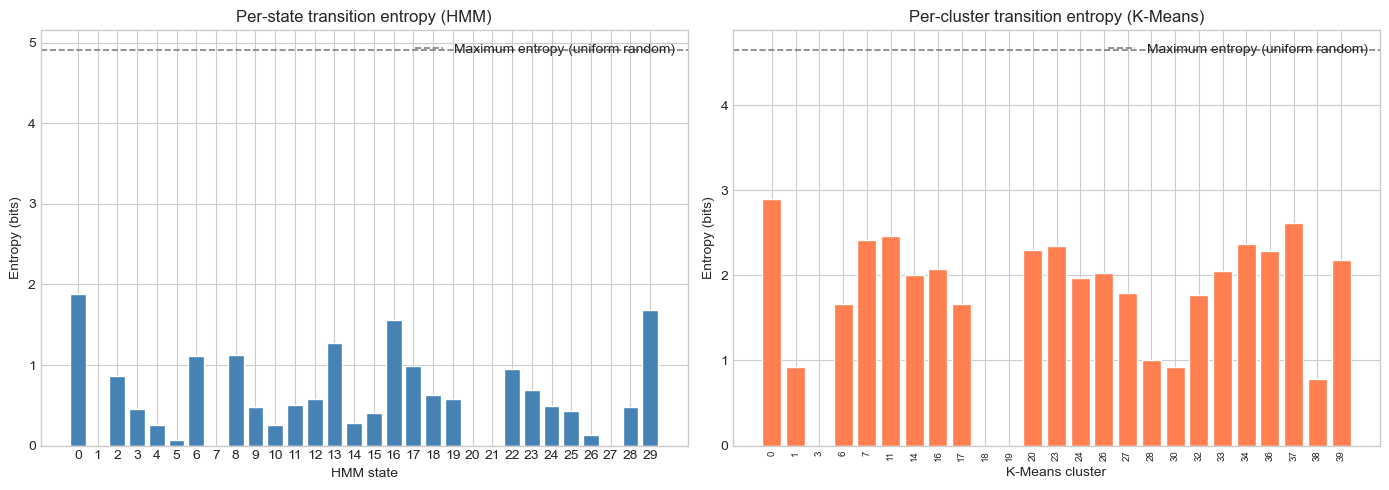

Most predictable HMM state (lowest entropy): state 1 (H = 0.0000 bits)
Least predictable HMM state (highest entropy): state 0 (H = 1.8785 bits)
Mean entropy — HMM: 0.6047 bits | K-Means: 1.6986 bits
Maximum possible (uniform) — HMM: 4.9069 bits | K-Means: 4.6439 bits
Interpretation: lower mean entropy indicates more structured / less uniform transitions.


In [31]:
P_hmm = np.asarray(final_hmm.transmat_, dtype=float)
P_km = np.asarray(prob_mat, dtype=float)

def row_entropies(P):
    H = []
    for i in range(P.shape[0]):
        row = np.clip(P[i], 0.0, 1.0)
        s = row.sum()
        if s <= 0:
            H.append(np.nan)
        else:
            H.append(stats.entropy(row / s, base=2))
    return np.array(H, dtype=float)

H_hmm = row_entropies(P_hmm)
H_km = row_entropies(P_km)

max_H_hmm = np.log2(P_hmm.shape[0])
max_H_km = np.log2(P_km.shape[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_h = np.arange(len(H_hmm))
axes[0].bar(x_h, H_hmm, color="steelblue", edgecolor="white")
axes[0].axhline(max_H_hmm, color="gray", ls="--", lw=1.2, label="Maximum entropy (uniform random)")
axes[0].set_xticks(x_h)
axes[0].set_xticklabels([str(int(s)) for s in hmm_labels_list])
axes[0].set_xlabel("HMM state")
axes[0].set_ylabel("Entropy (bits)")
axes[0].set_title("Per-state transition entropy (HMM)")
axes[0].legend(loc="upper right")

x_k = np.arange(len(H_km))
axes[1].bar(x_k, H_km, color="coral", edgecolor="white")
axes[1].axhline(max_H_km, color="gray", ls="--", lw=1.2, label="Maximum entropy (uniform random)")
axes[1].set_xticks(x_k)
axes[1].set_xticklabels([str(labels_sorted[i]) for i in range(len(labels_sorted))], rotation=90, fontsize=7)
axes[1].set_xlabel("K-Means cluster")
axes[1].set_ylabel("Entropy (bits)")
axes[1].set_title("Per-cluster transition entropy (K-Means)")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

hmm_valid = np.nan_to_num(H_hmm, nan=np.inf)
most_pred_idx = int(np.nanargmin(H_hmm))
least_pred_idx = int(np.nanargmax(H_hmm))

print(f"Most predictable HMM state (lowest entropy): state {most_pred_idx} (H = {H_hmm[most_pred_idx]:.4f} bits)")
print(f"Least predictable HMM state (highest entropy): state {least_pred_idx} (H = {H_hmm[least_pred_idx]:.4f} bits)")
print(f"Mean entropy — HMM: {np.nanmean(H_hmm):.4f} bits | K-Means: {np.nanmean(H_km):.4f} bits")
print(f"Maximum possible (uniform) — HMM: {max_H_hmm:.4f} bits | K-Means: {max_H_km:.4f} bits")
print("Interpretation: lower mean entropy indicates more structured / less uniform transitions.")


# Random walk simulation


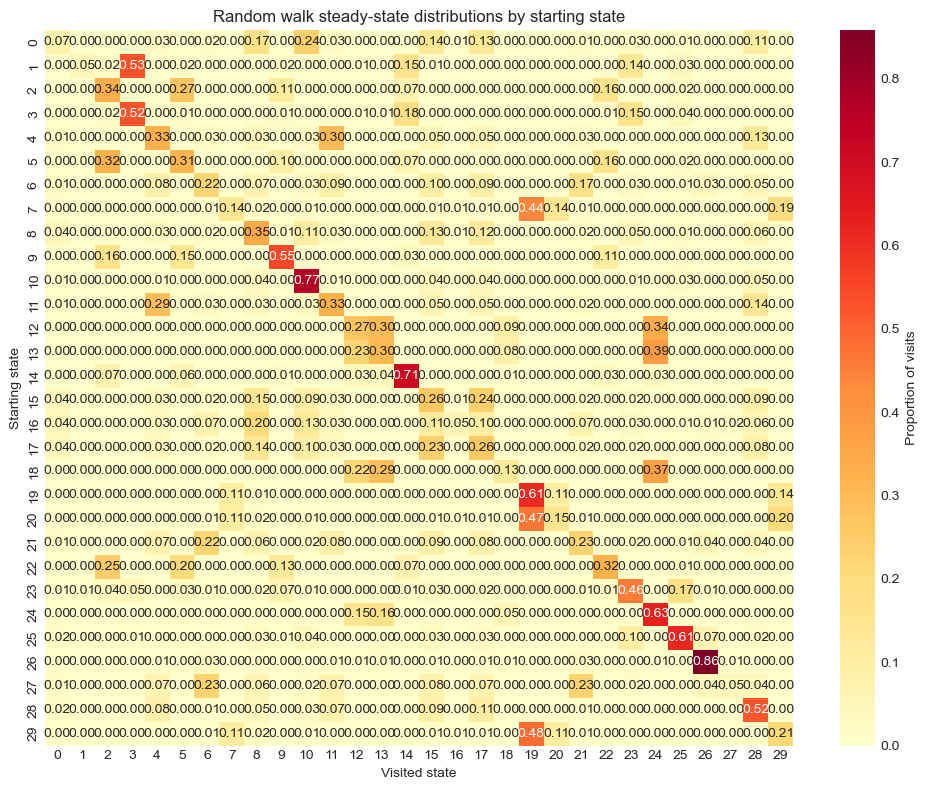

In [37]:
def simulate_random_walk(transmat, start_state, n_steps):
    """Sample a Markov chain for ``n_steps`` transitions (path length n_steps + 1)."""
    transmat = np.asarray(transmat, dtype=float)
    n_states = transmat.shape[0]
    path = [int(start_state)]
    cur = int(start_state)
    for _ in range(int(n_steps)):
        p = transmat[cur].astype(float)
        ps = p.sum()
        if ps <= 0:
            nxt = int(np.random.randint(0, n_states))
        else:
            p = p / ps
            nxt = int(np.random.choice(n_states, p=p))
        path.append(nxt)
        cur = nxt
    return path

rng = np.random.default_rng()
P = np.asarray(final_hmm.transmat_, dtype=float)
n_states = P.shape[0]
n_walks = 1000
walk_len = 20  # transitions after start

visit_prop = np.zeros((n_states, n_states), dtype=float)
for s0 in range(n_states):
    counts = np.zeros(n_states, dtype=float)
    for _ in range(n_walks):
        path = simulate_random_walk(P, s0, walk_len)
        for st in path:
            counts[st] += 1.0
    visit_prop[s0] = counts / counts.sum()

plt.figure(figsize=(10, 8))
sns.heatmap(
    visit_prop,
    cmap="YlOrRd",
    annot=True,
    fmt=".2f",
    xticklabels=hmm_labels_list,
    yticklabels=hmm_labels_list,
    cbar_kws={"label": "Proportion of visits"},
)
plt.xlabel("Visited state")
plt.ylabel("Starting state")
plt.title("Random walk steady-state distributions by starting state")
plt.tight_layout()
plt.show()


# Stationary distribution


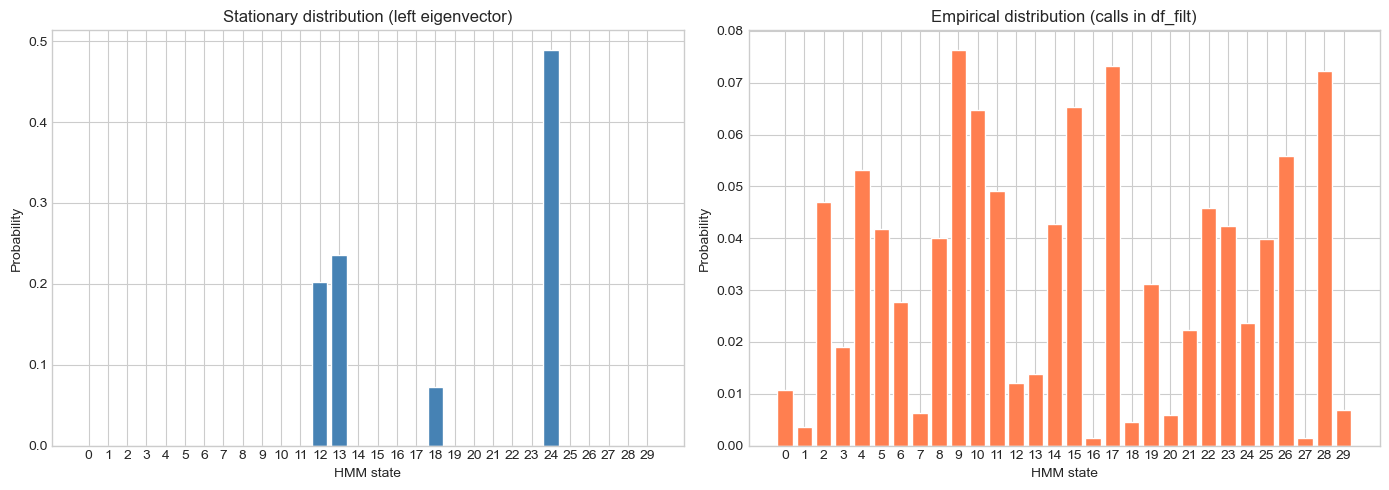

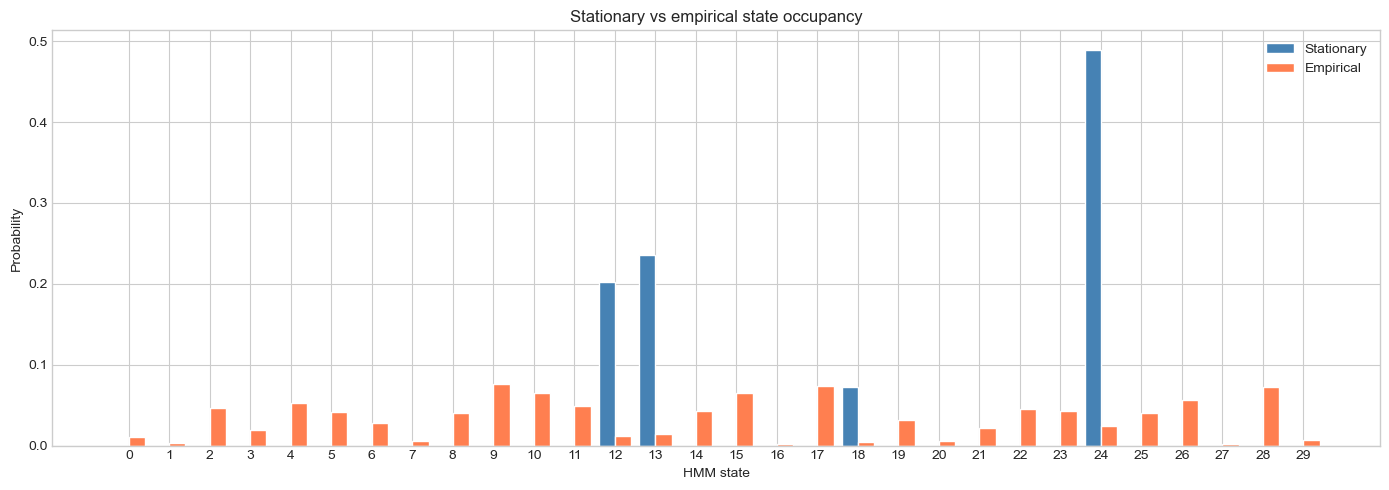

Correlation (stationary vs empirical): -0.2198
Interpretation: high correlation means observed call-level state frequencies align with the long-run Markov prediction.


In [33]:
w, V = np.linalg.eig(P_hmm.T)
j = int(np.argmin(np.abs(w - 1.0)))
pi = np.real(V[:, j])
pi = np.clip(pi, 0.0, None)
pi = pi / pi.sum()

empirical = df_filt["hmm_state"].value_counts().reindex(range(n_hmm), fill_value=0).values.astype(float)
empirical = empirical / empirical.sum()

corr_pi = float(np.corrcoef(pi, empirical)[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xh = np.arange(n_hmm)
axes[0].bar(xh, pi, color="steelblue", edgecolor="white")
axes[0].set_xticks(xh)
axes[0].set_xticklabels([str(s) for s in hmm_labels_list])
axes[0].set_xlabel("HMM state")
axes[0].set_ylabel("Probability")
axes[0].set_title("Stationary distribution (left eigenvector)")

axes[1].bar(xh, empirical, color="coral", edgecolor="white")
axes[1].set_xticks(xh)
axes[1].set_xticklabels([str(s) for s in hmm_labels_list])
axes[1].set_xlabel("HMM state")
axes[1].set_ylabel("Probability")
axes[1].set_title("Empirical distribution (calls in df_filt)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 5))
wbar = 0.4
ax.bar(xh - wbar / 2, pi, width=wbar, label="Stationary", color="steelblue", edgecolor="white")
ax.bar(xh + wbar / 2, empirical, width=wbar, label="Empirical", color="coral", edgecolor="white")
ax.set_xticks(xh)
ax.set_xticklabels([str(s) for s in hmm_labels_list])
ax.set_xlabel("HMM state")
ax.set_ylabel("Probability")
ax.set_title("Stationary vs empirical state occupancy")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Correlation (stationary vs empirical): {corr_pi:.4f}")
print("Interpretation: high correlation means observed call-level state frequencies align with the long-run Markov prediction.")
